# Minimal Workflow Demonstration

In [1]:
import superstats as sup
import pandas as pd

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
E0716 23:33:39.059138 2051960 cuda_executor.cc:1182] [0] Failed to allocate device memory of 17.64GiB (18939379712 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [2]:
NUM_STEPS = 100

## Specify an Observation Model

In [3]:
obs_model = sup.simulation.cognitive.sample_ddm

## Specify a Joint Prior

Each model parameter prior can be specified via the following options:
- A `Transition` $\rightarrow$ `local_param` (time-varying, estimated)
- A `Prior` $\rightarrow$ `shared_param` (time-invariant, estimated)
- A `scalar` $\rightarrow$ `fixed_param` (time-varying, not estimated)

In [4]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
        bounds=(0, 6),
    ),
    a = sup.transition.RandomWalk(
        bounds=(0.2, 4)
    ),
    tau = sup.prior.Prior("halfnormal", scale=0.5),
    bias = 0.5
)

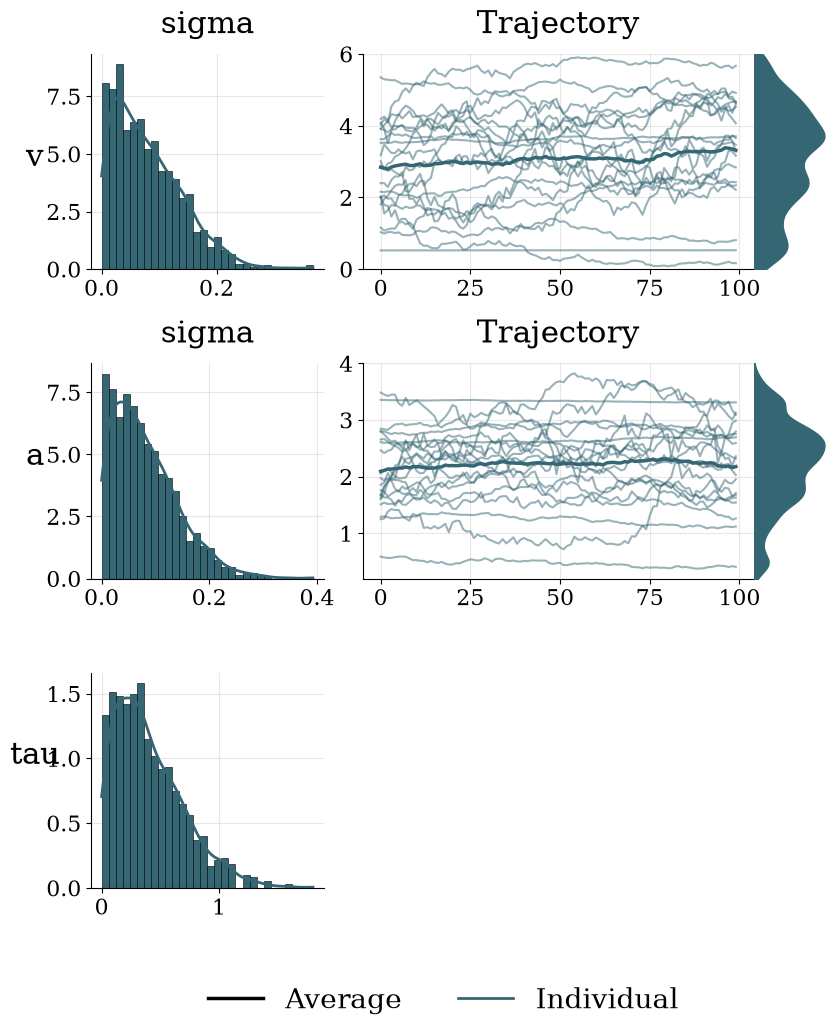

In [5]:
fig = joint_prior.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_draws=1000,
    num_trajectories=20
)

## Specify a Generative Model

In [6]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=obs_model,
)

In [7]:
sim_data = generative_model.sample(batch_size=10, num_steps=NUM_STEPS)

In [8]:
print(
    "Dict keys: ", sim_data.keys(), "\n",
    "Shape of response_time: ", sim_data["response_time"].shape, "\n",
    "Shape of a time-varying param: ", sim_data["v"].shape, "\n",
    "Shape of a time-invariant param: ", sim_data["v_sigma"].shape, "\n",
    sep=""
)

Dict keys: dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'v_sigma', 'a_sigma', 'tau'])
Shape of response_time: (10, 100)
Shape of a time-varying param: (10, 100, 1)
Shape of a time-invariant param: (10, 1)



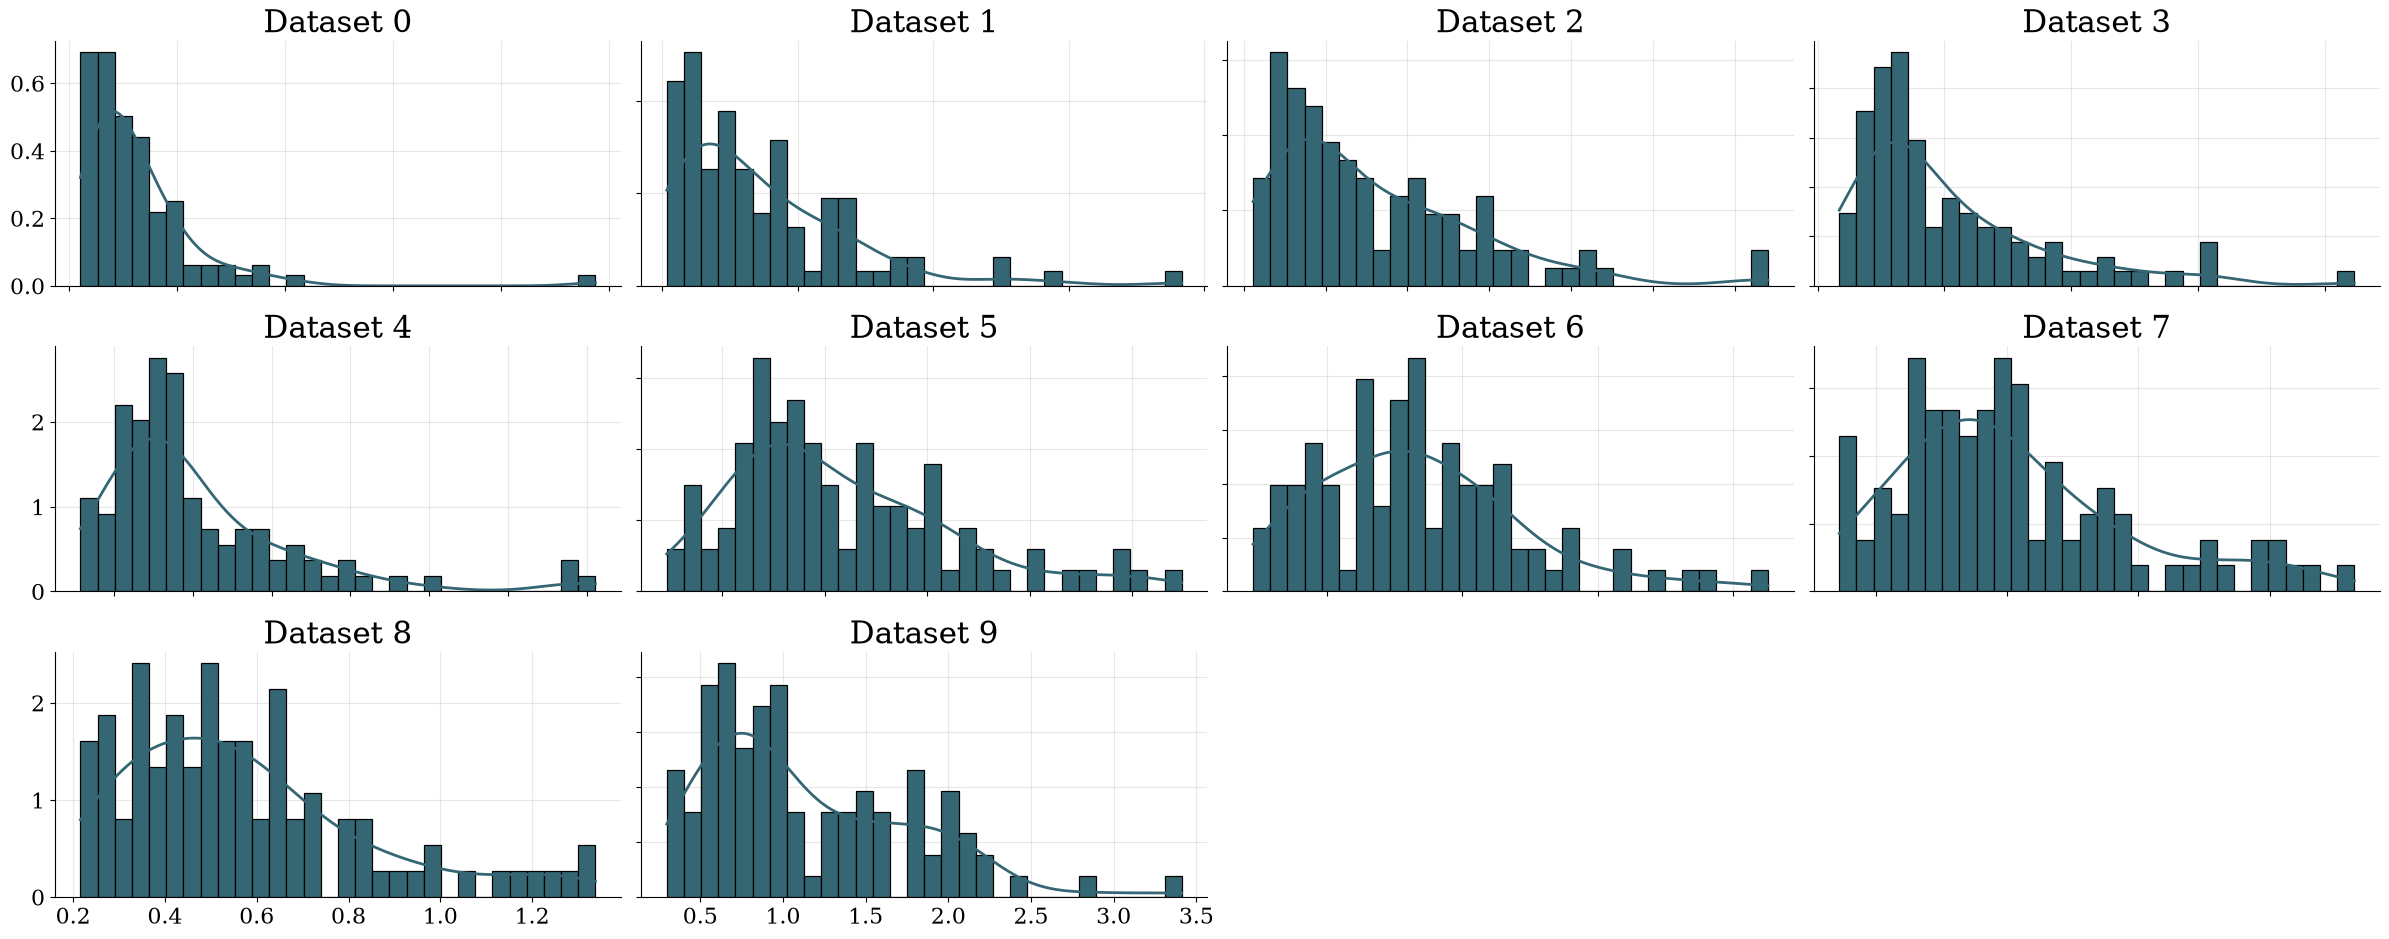

In [9]:
fig = generative_model.plot_push_forward(
    num_sim=10,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    aggregation=None,
    num_cols=4
)

## Set up amortized Bayesian Workflow 

In [10]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="checkpoints/minimal_demo_v2"
)

Here, users can provide summary and inference networks. Default networks are used if nothing is provided.

## Approximator Training

### Offline Training

Use offline training for fast iteration of the model develop and verification cicle

In [11]:
train_data = workflow.simulator.sample(
    batch_size=25000,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
test_data = workflow.simulator.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [12]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=test_data,
    epochs=50,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 5.6210 - val_loss: 4.9193
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 4.4868 - val_loss: 4.5785
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 4.1825 - val_loss: 4.1867
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 3.9228 - val_loss: 4.1661
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 3.7452 - val_loss: 3.8416
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 3.4881 - val_loss: 3.4592
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 3.2264 - val_loss: 3.2242
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 3.0642 - val_loss: 3.1323
Epoch 9/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 2.9198 - val_loss: 2.8647
Epoch 10/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 2.7823 - val_loss: 2.7609
Epoch 11/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 2.6762 - val_loss: 2.7958
Epoch 12/50
782/782 ━━━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training completed in 7.16 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'checkpoints/minimal_demo_v2/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("checkpoints/minimal_demo_v2/model.keras")


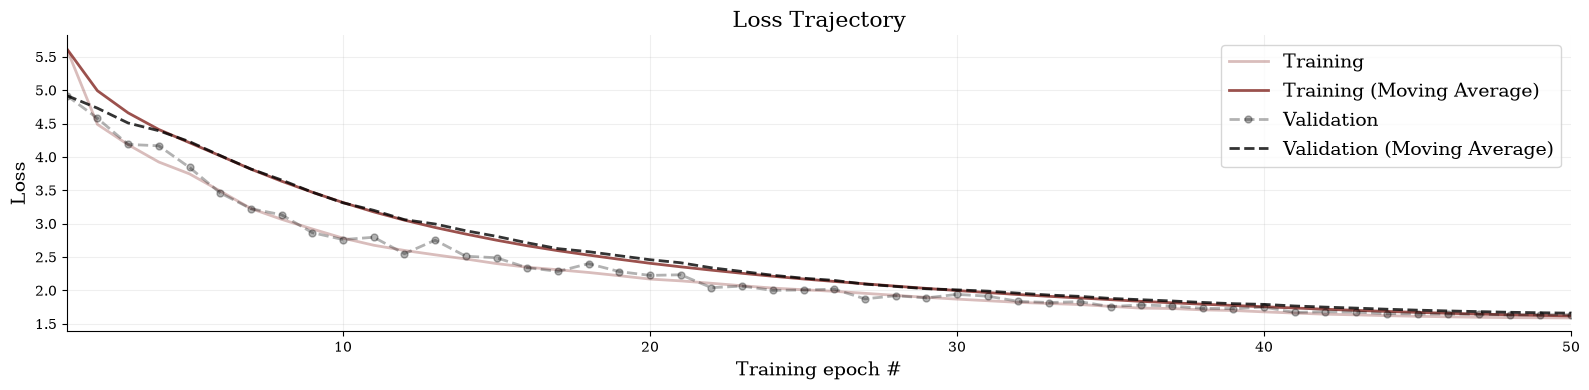

In [13]:
fig = workflow.plot_history(history)

### Online Training

Use online training for final maximal performance

In [ ]:
history = workflow.fit_online(
    num_steps=800,
    epochs=50,
    num_batches_per_epoch=1000,
    batch_size=32
)

In [ ]:
fig = workflow.plot_history(history)

## Model Verification

Simulate some data for verification

In [17]:
targets = workflow.simulator.sample(
    batch_size=250,
    num_steps=NUM_STEPS,
)

Fit the model to the simulated data

In [18]:
estimates = workflow.sample(
    data=targets,
    num_samples=500,
    batch_size=2
)

Summarizing:   0%|          | 0/125 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/125 [00:00<?, ?batch/s]

### Time-varying Parameters

Plot four diagnostic metrics for the time-varying parameters across time:
1. Pearson correlation between true parameter and posterior median
2. Normalized root mean squared error between true parameter and posterior median
3. Posterior contraction
4. Simulation-based calibration error

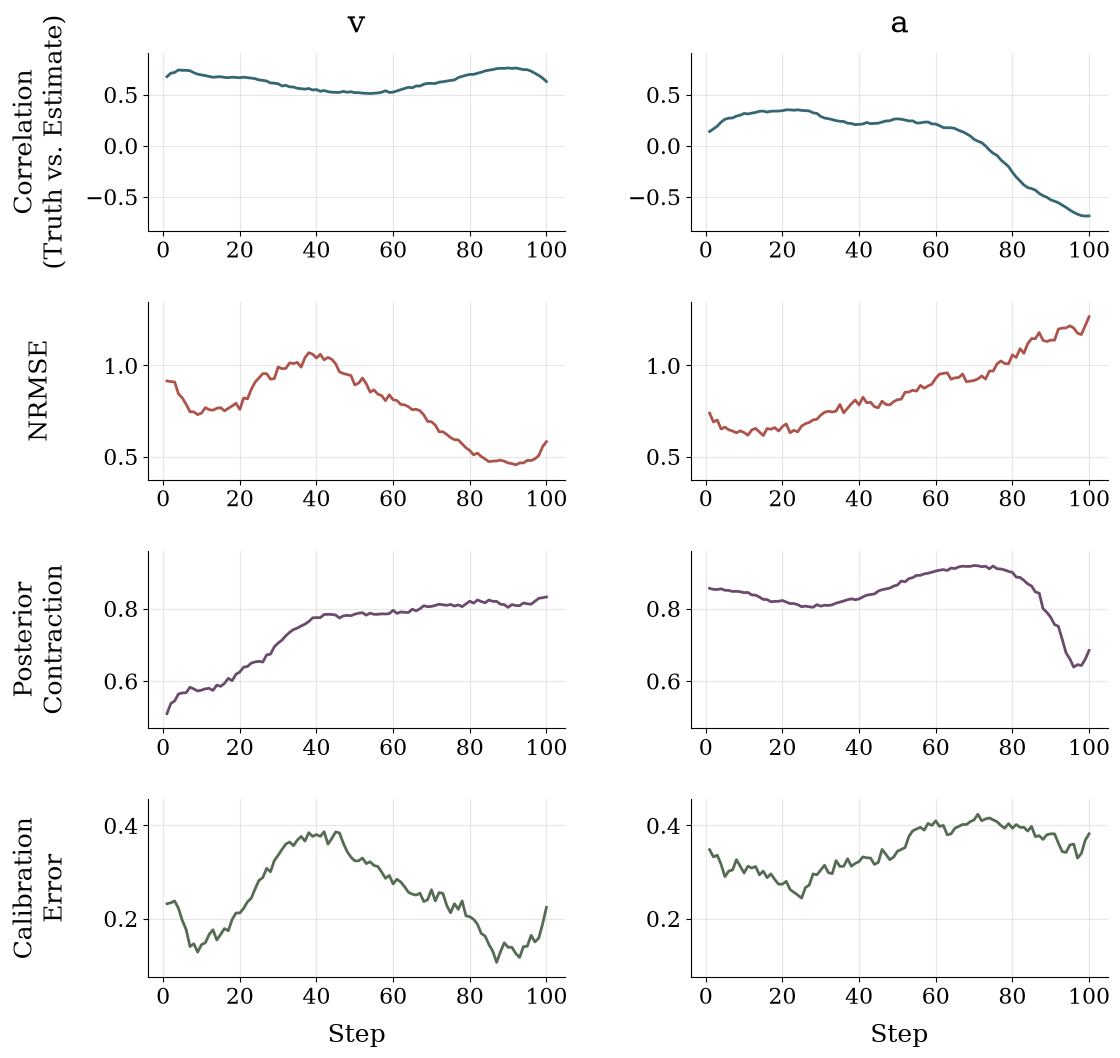

In [19]:
fig = workflow.verify_time_varying(
    targets=targets,
    estimates=estimates
)

### Time-invariant Parameters

Plot recovery and simulation-based calibration for time-invariant parameters

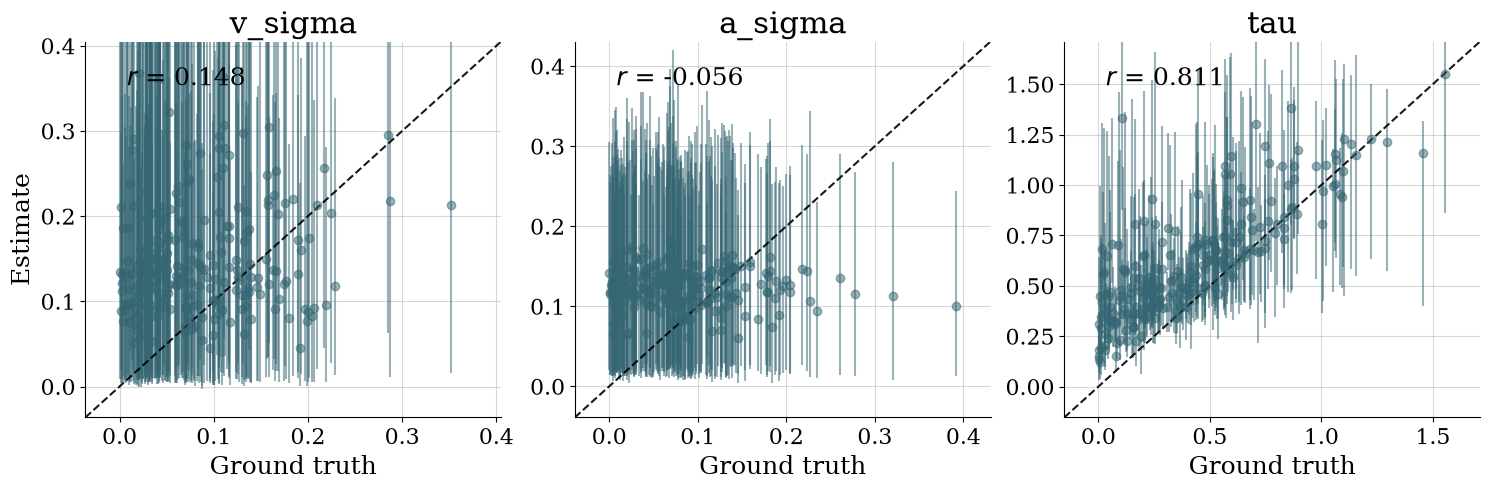

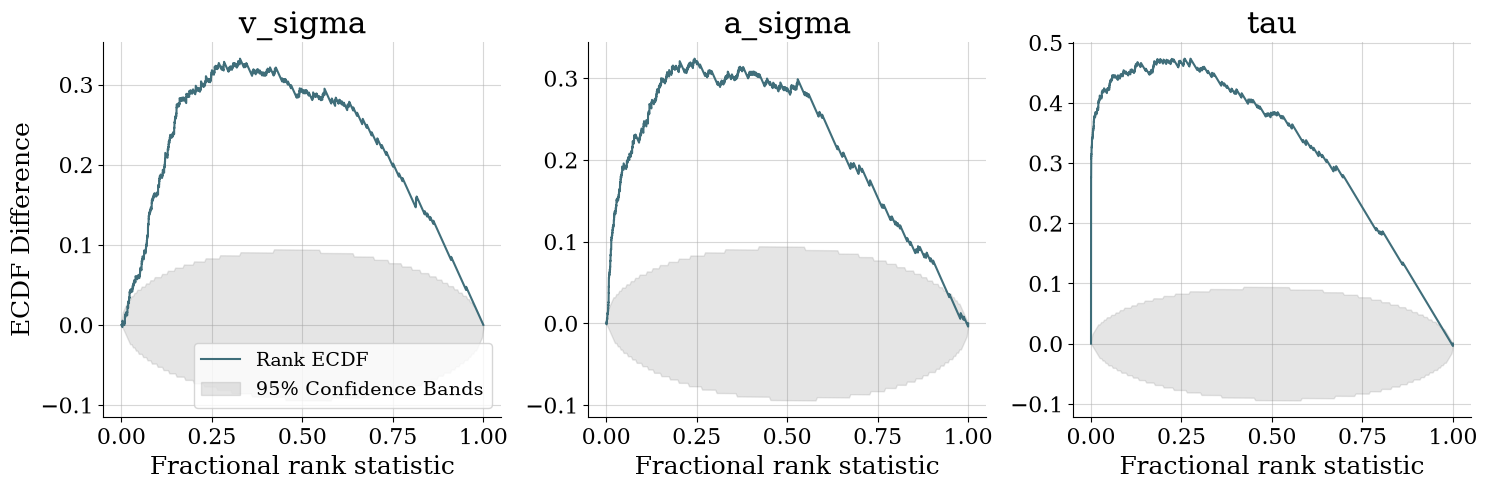

In [20]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    estimates=estimates,
    targets=targets
)

## Fit Empirical Data

The empirical data needs to be in same shape as simulated data, which means we need a `ndarray` with shape `(num_datasets, num_steps, data_dims)`.

In [3]:
df = pd.read_csv("data/data_color_discrimination.csv")
empiric_data = sup.utils.df_to_array(df, id_col="id", data_cols=("rt", "correct"))
empiric_data.shape

(14, 768, 2)

In [ ]:
samples = workflow.sample(
    data=empiric_data,
    num_samples=500
)

## Posterior Re-simulation

## Posterior Estimates